In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv('exchange_rate.csv')
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [11]:
df.isnull().sum()

date       0
Ex_rate    0
dtype: int64

In [12]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [14]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


# Part 1: Data Exploration

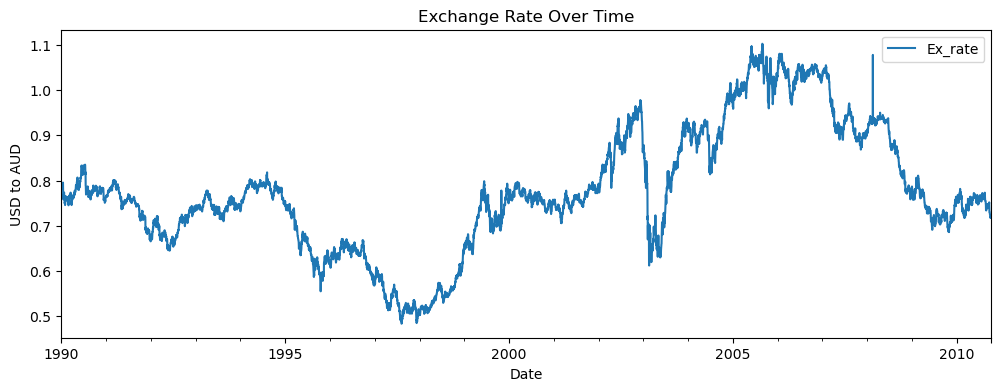

In [15]:
df.plot(figsize=(12, 4))
plt.title('Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('USD to AUD')
plt.show()

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

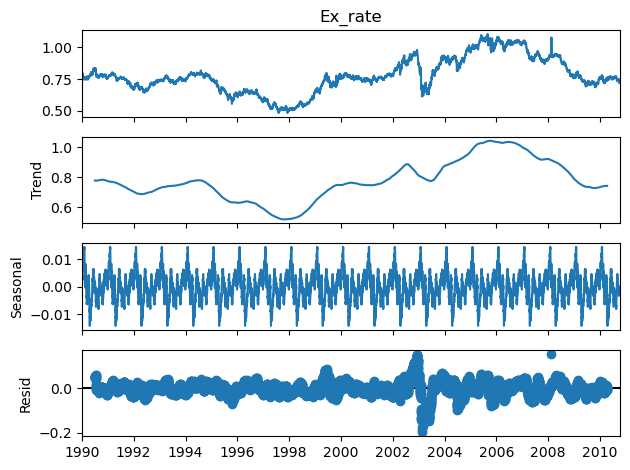

In [17]:
decompose=seasonal_decompose(df['Ex_rate'],model='additive',period=365)
decompose.plot()
plt.tight_layout()
plt.show()

# The trend shows a long-term rise and fall in the exchange rate. Seasonality is weak. Residuals look mostly random which is a good sign.

In [18]:
# train/test split — last 30 days as test
train = df['Ex_rate'][:-30]
test  = df['Ex_rate'][-30:]
print("Train size:", len(train), "| Test size:", len(test))

Train size: 7558 | Test size: 30


# Part 2: ARIMA Model

In [19]:
from statsmodels.tsa.stattools import adfuller

In [20]:
result=adfuller(df['Ex_rate'])
print("ADF Statistic:",round(result[0], 4))
print("p-value:",round(result[1], 4))
if result[1]>0.05:
    print("Not stationary — differencing needed (d=1)")
else:
    print("Stationary")

ADF Statistic: -1.665
p-value: 0.4492
Not stationary — differencing needed (d=1)


In [21]:
df_diff=df['Ex_rate'].diff().dropna()

In [22]:
result2=adfuller(df_diff)
print("After differencing — p-value:",round(result2[1], 4))
if result2[1]<=0.05:
    print("Now stationary — d=1 confirmed")

After differencing — p-value: 0.0
Now stationary — d=1 confirmed


In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

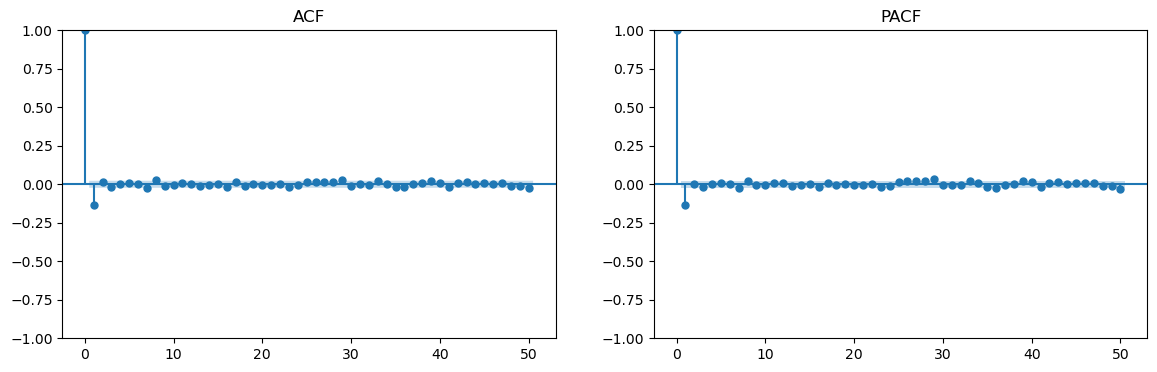

In [24]:
fig, axes=plt.subplots(1,2,figsize=(14,4))
plot_acf(df_diff,lags=50,ax=axes[0])
plot_pacf(df_diff,lags=50,ax=axes[1])
axes[0].set_title('ACF')
axes[1].set_title('PACF')
plt.show()

# ACF cuts off quickly and PACF drops after lag 1 — this suggests p=1, d=1, q=1 for ARIMA.

In [25]:
from statsmodels.tsa.arima.model import ARIMA

In [26]:
arima_model=ARIMA(train,order=(1,1,1))
arima_result=arima_model.fit()
arima_result.summary()

C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Ex_rate   No. Observations:                 7558
Model:                 ARIMA(1, 1, 1)   Log Likelihood               27934.471
Date:                Mon, 13 Apr 2026   AIC                         -55862.942
Time:                        16:52:34   BIC                         -55842.152
Sample:                    01-01-1990   HQIC                        -55855.806
                         - 09-10-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1262      0.045     -2.783      0.005      -0.215      -0.037
ma.L1         -0.0056      0.045     -0.123      0.902      -0.095       0.083
sigma2      3.604e-05   9.99e-08    360.760      0.000    3.58e-05    3.62e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           2846316.17
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.98   Skew:                             0.25
Prob(H) (two-sided):                  0.00   Kurtosis:                        98.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

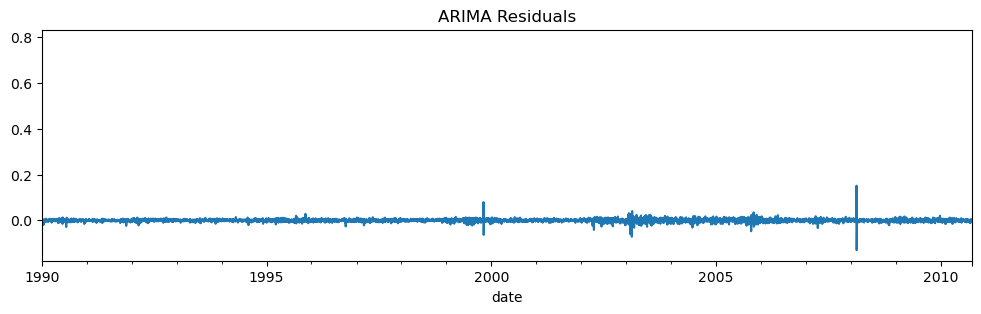

In [28]:
arima_result.resid.plot(figsize=(12, 3))
plt.title('ARIMA Residuals')
plt.show()

In [29]:
arima_forecast=arima_result.forecast(steps=30)

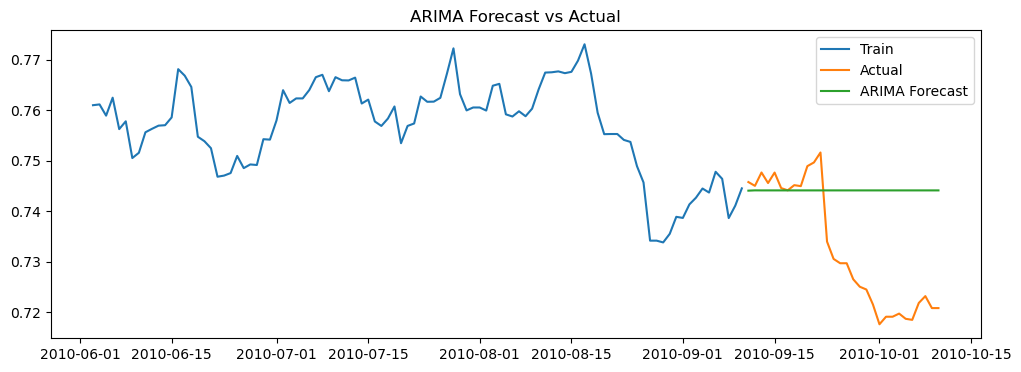

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(train[-100:], label='Train')
plt.plot(test, label='Actual')
plt.plot(arima_forecast, label='ARIMA Forecast')
plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.show()

# Part 3: Exponential Smoothing Model

In [31]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
es_model=ExponentialSmoothing(train,trend='add',seasonal=None)
es_result=es_model.fit()
es_forecast=es_result.forecast(steps=30)

C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


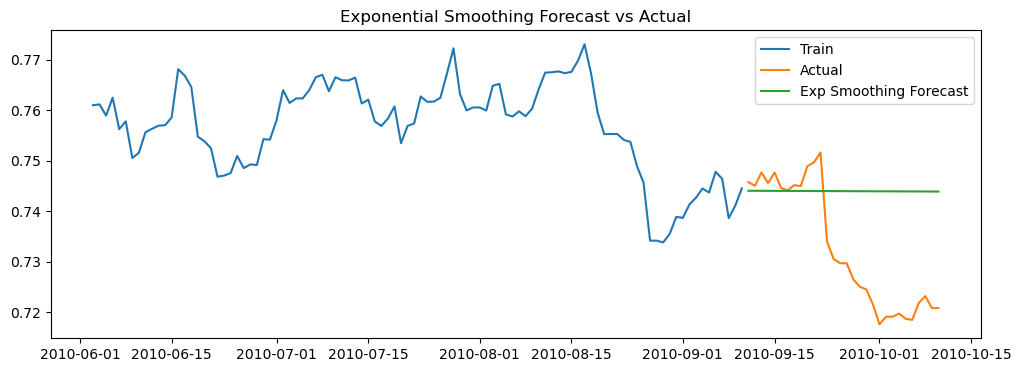

In [32]:
plt.figure(figsize=(12,4))
plt.plot(train[-100:],label='Train')
plt.plot(test,label='Actual')
plt.plot(es_forecast,label='Exp Smoothing Forecast')
plt.title('Exponential Smoothing Forecast vs Actual')
plt.legend()
plt.show()

# Evaluation and Comparison

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def mape(actual,predicted):
    return np.mean(np.abs((actual-predicted)/actual))*100

In [35]:
mae_arima=mean_absolute_error(test,arima_forecast)
rmse_arima=np.sqrt(mean_squared_error(test,arima_forecast))
mape_arima=mape(test.values,arima_forecast.values)

In [36]:
mae_es=mean_absolute_error(test,es_forecast)
rmse_es=np.sqrt(mean_squared_error(test,es_forecast))
mape_es=mape(test.values,es_forecast.values)

In [41]:
print("ARIMA errors -> MAE:", round(mae_arima,4), "RMSE:", round(rmse_arima,4), "MAPE:", round(mape_arima,4))
print("Exp Sm errors -> MAE:", round(mae_es,4), "RMSE:", round(rmse_es,4), "MAPE:", round(mape_es,4))

ARIMA errors -> MAE: 0.0135 RMSE: 0.0166 MAPE: 1.8632
Exp Sm errors -> MAE: 0.0134 RMSE: 0.0165 MAPE: 1.8535


In [42]:
compare = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE'  : [round(mae_arima,4),  round(mae_es,4)],
    'RMSE' : [round(rmse_arima,4), round(rmse_es,4)],
    'MAPE' : [round(mape_arima,4), round(mape_es,4)]
})
compare

,Model,MAE,RMSE,MAPE
0,ARIMA,0.0135,0.0166,1.8632
1,Exponential Smoothing,0.0134,0.0165,1.8535
